In [1]:
import os
import shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
import seaborn as sns
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# source_dir = r"C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Fotos planta"
# output_dir = r"C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Fotos planta mezcladas"

# train_ratio = 0.7
# val_ratio = 0.15
# test_ratio = 0.15

# classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

# for cls in classes:
#    class_path = os.path.join(source_dir, cls)
#    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
   
#    train_imgs, temp_imgs = train_test_split(
#        images, 
#        test_size=(val_ratio + test_ratio), 
#        random_state=42
#    )
   
#    relative_test_size = test_ratio / (val_ratio + test_ratio)
#    val_imgs, test_imgs = train_test_split(
#        temp_imgs, 
#        test_size=relative_test_size, 
#        random_state=42
#    )
   
#    splits = {
#        'train': train_imgs, 
#        'val': val_imgs, 
#        'test': test_imgs
#    }
   
#    for split_name, split_imgs in splits.items():
#        destination_path = os.path.join(output_dir, split_name, cls)
#        os.makedirs(destination_path, exist_ok=True)
       
#        for img in split_imgs:
#            shutil.copy(os.path.join(class_path, img), os.path.join(destination_path, img))
           
#    print(f"Class '{cls}': Total {len(images)} images -> Split into {len(train_imgs)} train, {len(val_imgs)} val, {len(test_imgs)} test.")

# print("\nData splitting complete! All data preserved.")

In [3]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Fotos planta mezcladas\train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Fotos planta mezcladas\val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Fotos planta mezcladas\test",
    image_size=IMG_SIZE, # Make sure this matches your model (e.g., (224, 224) or (100, 100))
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False # Keep false for test data so your evaluation metrics align perfectly
)

all_labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0).flatten()
counter = Counter(all_labels)
total_samples = len(all_labels)

class_weight = {
    0: total_samples / (2.0 * counter[0.0]),
    1: total_samples / (2.0 * counter[1.0])
}

print(f"Calculated Class Weights to balance the loss function: {class_weight}")


Found 212 files belonging to 2 classes.
Found 45 files belonging to 2 classes.
Found 47 files belonging to 2 classes.
Calculated Class Weights to balance the loss function: {0: 0.5668449197860963, 1: 4.24}


In [4]:
model= models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 49, 49, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 47, 47, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 23, 23, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 21, 21, 64)        36928     
                                                                 
 flatten (Flatten)           (None, 28224)             0

In [5]:
history = model.fit(train_ds, validation_data=val_ds, epochs=30, class_weight=class_weight)

test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

Epoch 1/30
7/7 [==============================] - 3s 98ms/step - loss: 66.9557 - accuracy: 0.5943 - val_loss: 1.7036 - val_accuracy: 0.1111
Epoch 2/30
7/7 [==============================] - 0s 32ms/step - loss: 0.7856 - accuracy: 0.6934 - val_loss: 0.5159 - val_accuracy: 0.8667
Epoch 3/30
7/7 [==============================] - 0s 32ms/step - loss: 0.8791 - accuracy: 0.8349 - val_loss: 0.6139 - val_accuracy: 0.6889
Epoch 4/30
7/7 [==============================] - 0s 35ms/step - loss: 0.7235 - accuracy: 0.7830 - val_loss: 0.6408 - val_accuracy: 0.4889
Epoch 5/30
7/7 [==============================] - 0s 37ms/step - loss: 1.0395 - accuracy: 0.5802 - val_loss: 0.5031 - val_accuracy: 0.7333
Epoch 6/30
7/7 [==============================] - 0s 37ms/step - loss: 0.6739 - accuracy: 0.2689 - val_loss: 0.7041 - val_accuracy: 0.1111
Epoch 7/30
7/7 [==============================] - 0s 32ms/step - loss: 0.6933 - accuracy: 0.1226 - val_loss: 0.7044 - val_accuracy: 0.1111
Epoch 8/30
7/7 [==========

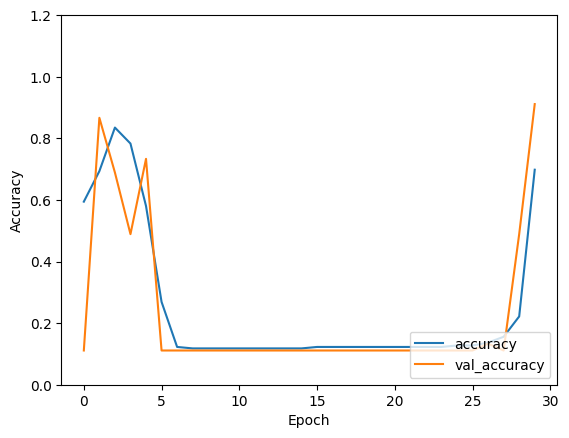

In [8]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1.2])
plt.legend(loc='lower right')
plt.show()

2/2 [==============================] - 0s 7ms/step
True labels array size: 47
Predicted labels array size: 47


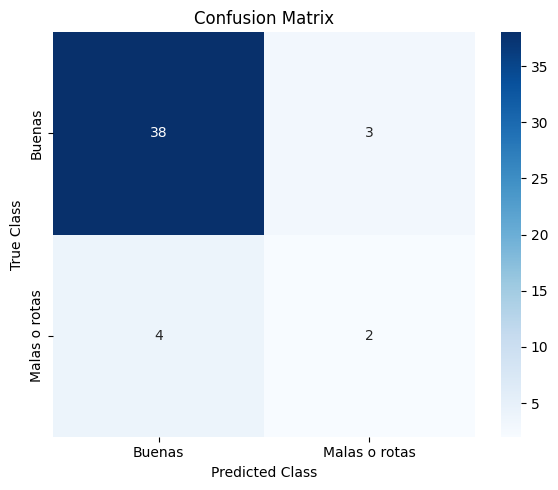


Classification Report:

               precision    recall  f1-score   support

       Buenas       0.90      0.93      0.92        41
Malas o rotas       0.40      0.33      0.36         6

     accuracy                           0.85        47
    macro avg       0.65      0.63      0.64        47
 weighted avg       0.84      0.85      0.85        47



In [7]:
test_images = []
true_labels = []

for images, labels in test_ds:
    test_images.append(images.numpy())
    true_labels.append(labels.numpy())

test_images = np.concatenate(test_images, axis=0)
true_labels = np.concatenate(true_labels, axis=0).flatten().astype(int)

predictions = model.predict(test_images)

predicted_labels = (predictions > 0.5).astype(int).flatten()

print(f"True labels array size: {true_labels.shape[0]}")
print(f"Predicted labels array size: {predicted_labels.shape[0]}")

cm = confusion_matrix(true_labels, predicted_labels)

class_names = test_ds.class_names 

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,          
    fmt='d',             
    cmap='Blues',        
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_names))